Data points collected: 280653
Position bounds: -509 to 509
Fragment size bounds: 40 to 500


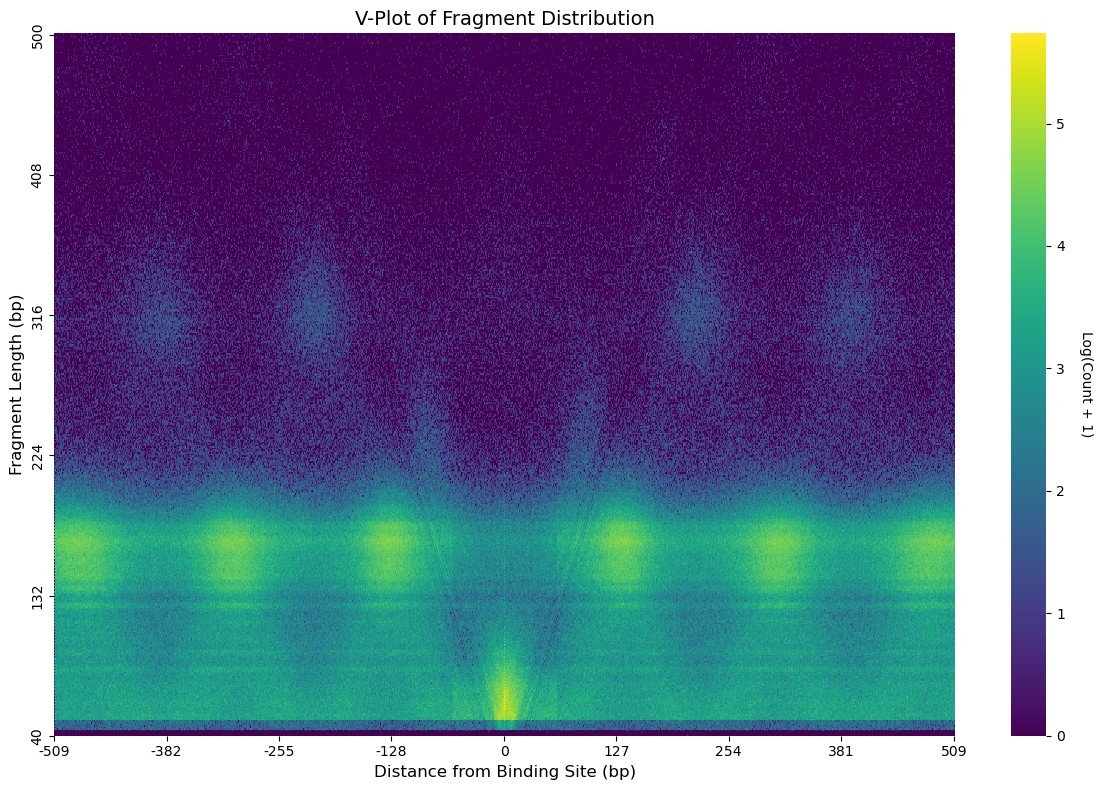

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import gzip

def generate_vplot_matrix(file_path, max_dist=1000, max_len=500):
    pos_len_counts = defaultdict(int)
    with gzip.open(file_path, 'rt') as f:
        for line_num, line in enumerate(f, 1):
            try:
                fields = line.strip().split('\t')
                protein_center = (int(fields[2]) + int(fields[3])) / 2
                frag_center = (int(fields[8]) + int(fields[9])) / 2
                rel_pos = int(frag_center - protein_center)
                frag_len = int(fields[9]) - int(fields[8])
                if abs(rel_pos) <= max_dist and frag_len <= max_len:
                    pos_len_counts[(rel_pos, frag_len)] += 1
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line {line_num}: {e}")
                continue
    pos_vals = sorted({p for p, _ in pos_len_counts})
    len_vals = sorted({l for _, l in pos_len_counts})
    print(f"Data points collected: {len(pos_len_counts)}")
    print(f"Position bounds: {min(pos_vals)} to {max(pos_vals)}")
    print(f"Fragment size bounds: {min(len_vals)} to {max(len_vals)}")
    heatmap_matrix = np.zeros((len(len_vals), len(pos_vals)))
    for r, frag in enumerate(len_vals):
        for c, pos in enumerate(pos_vals):
            heatmap_matrix[r, c] = pos_len_counts.get((pos, frag), 0)
    return pos_vals, len_vals, heatmap_matrix

try:
    input_path = "mapped.bed.gz"
    x_coords, y_coords, heatmap_data = generate_vplot_matrix(input_path)
    plt.figure(figsize=(12, 8))
    log_data = np.log1p(heatmap_data)
    plot = sns.heatmap(log_data, cmap='viridis', xticklabels=500, yticklabels=50)
    xtick_pos = np.linspace(0, len(x_coords)-1, 9).astype(int)
    xtick_lbl = [x_coords[i] for i in xtick_pos]
    plt.xticks(xtick_pos, xtick_lbl)
    ytick_pos = np.linspace(0, len(y_coords)-1, 6).astype(int)
    ytick_lbl = [y_coords[i] for i in ytick_pos]
    plt.yticks(ytick_pos, ytick_lbl)
    plt.xlabel('Distance from Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Length (bp)', fontsize=12)
    plt.title('V-Plot of Fragment Distribution', fontsize=14)
    plt.gca().invert_yaxis()
    cb = plot.collections[0].colorbar
    cb.set_label('Log(Count + 1)', rotation=270, labelpad=20)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print(f"Error: File '{input_path}' not found")
except Exception as e:
    print(f"Visualization error: {str(e)}")
